# Import

In [1]:
import os
import gc
import random
from tqdm import tqdm, trange

import numpy as np
import pandas as pd
from pandas import DataFrame
import matplotlib.pyplot as plt
from scipy import signal

import torch
from torch import tensor
from torch.optim import RMSprop, Adam, NAdam, SGD, Adamax, Adadelta, AdamW, LBFGS, Adagrad
from torch.utils.data import random_split, DataLoader
from torch.nn.functional import normalize
# from torch.utils.data import Dataset, TensorDataset

from datasets import Dataset, DatasetDict, load_from_disk

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

import shap
import pickle

from IPython.display import clear_output, Image as IPImage, display
import time

# Config

In [2]:
base = "Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
INTENSITIES = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]

DATA_DIR = 'Datasets/'
CP_DIR = 'Checkpoints/'
LOG_DIR = 'Log/'


torch.cuda.empty_cache()
gc.collect()

from torch import nn

class Config:
    EXPERIMETS = datasets = [
        "Mona Lisa",
        "Necker cube"
        ]
    RHYTHMS = signal_fiq = [
        'alpha',
        'beta',
        'delta',
        'gamma',
        'theta'
        ]
    MODELS = [
        'Big',
        'Small',
        'CNN'
        ]
    OPTIMIZER_LIST = [
        'Adadelta',
        'Adagrad',
        'Adam',
        'Adamax',
        'AdamW',
        'NAdam',
        'RMSprop',
        'SGD'
        ]
    signal_name = signal_fiq
    batch_size = 50
    threshold = 0.001
    seed = 42
    n_folds = 10
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # device = torch.device('cpu')
    epochs = 100
    in_features = 15000
    out_features  = 6400
    activation=nn.ReLU()
    loss_func = nn.CrossEntropyLoss()
    lr_patience = 5
    lr = 1e-5
    save_best_model = False

print(Config.device)

def set_seed(seed = 42):
    torch.initial_seed() % 2**32
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)
    gseed = torch.Generator().manual_seed(seed)
    # print(worker_seed)
    return gseed

set_seed(Config.seed)

cuda


# Robiul preparation

In [60]:
class EEG:
    def __init__(self, participant,datasets):

        self.int = {}
        self.delta = {}
        self.theta = {}
        self.alpha = {}
        self.beta = {}
        self.gamma = {}

        for dataset in datasets:
            if dataset == "Mona Lisa":
                Dname = "/Figs for spectra"
                var1 = "/Backgr_int_"
                var2 = ".dat"
            else:
                Dname = "/Cubes for spectra"
                var1 = "/Backgr_int_"
                var2 = "_type_0.4.dat"

        for intensity in INTENSITIES:
            S = os.path.join(base, "Participant " + str(participant) + Dname + var1 + str(intensity) + var2)
            I = intensity
            self.int[I] = np.loadtxt(S)
            delta_signal = np.empty(self.int[I].shape)
            theta_signal =  np.empty(self.int[I].shape)
            alpha_signal = np.empty(self.int[I].shape)
            beta_signal = np.empty(self.int[I].shape)
            gamma_signal = np.empty(self.int[I].shape)

            for c in range(self.int[I].shape[1]):
                delta_signal[:,c], theta_signal[:,c],alpha_signal[:, c], beta_signal[:, c],gamma_signal[:,c] = self.fir_filtering(I, c)
            self.delta[I] = delta_signal
            self.theta[I] = theta_signal
            self.alpha[I] = alpha_signal
            self.beta[I] = beta_signal 
            self.gamma[I] = gamma_signal

    def fir_filtering(self, I, c):
        filter_delta = signal.firwin(400, [1.0, 4.0], pass_zero=False, fs=250)
        filter_theta = signal.firwin(400, [5.0, 8.0], pass_zero=False, fs=250)
        filter_alpha = signal.firwin(400, [8.0, 12.0], pass_zero=False, fs=250)
        filter_beta = signal.firwin(400, [13.0, 30.0], pass_zero=False, fs=250)
        filter_gamma = signal.firwin(400, [31.0, 45.0], pass_zero=False, fs=250)
        res_delta = signal.convolve(self.int[I][:, c], filter_delta, mode='same')
        res_theta = signal.convolve(self.int[I][:, c], filter_theta, mode='same')
        res_alpha = signal.convolve(self.int[I][:, c], filter_alpha, mode='same')
        res_beta = signal.convolve(self.int[I][:, c], filter_beta, mode='same')
        res_gamma = signal.convolve(self.int[I][:, c], filter_gamma, mode='same')
        
        return res_delta,res_theta, res_alpha,res_beta,res_gamma 

In [61]:
Intencity = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
base = "/mnt/z/Robiul/Exploring-the-Relationship-between-Brain-Hemisphere-States-and-Frequency-Bands-through-Deep-Learning-main/"
file_path = os.path.join(base, "Channels.dat")
df_channels = pd.read_csv(file_path, header=None, sep='.')
channel_names = df_channels.iloc[:, -1:].values.flatten()

def convart_sin_fiq(fiq):
  if fiq == 'delta':
    return 1
  elif fiq == 'theta':
    return 2
  elif fiq == 'alpha':
    return 3
  elif fiq =='beta': 
    return 4
  elif fiq == 'gamma':
    return 5

def createdataframe(user,dataset,signal_fiq):
    global Intencity,channel_names
    tem_signal = []
    eeg_person = EEG(user,dataset)
    for i in Intencity:
        for ch in range(0,31):
            tem = [dataset,ch,channel_names[ch],convart_sin_fiq(signal_fiq),signal_fiq,i,user]
            # tem = [channel_names[ch]]
            S = 'tem_signal.append(np.append(tem, eeg_person.'+signal_fiq+'.get(i)[:,ch][0:15000]))'
            eval(S)
    
           
    tem_dataframe = pd.DataFrame(tem_signal)

    colunm = [] 

    colunm.append("Dataset")
    colunm.append("channel")
    colunm.append("Channel_Name")
    colunm.append("band")
    colunm.append("frequency")
    colunm.append("Intencity")
    colunm.append("participant")

    for col in range(0,15000):
      S = 'Time'+str(col)
      colunm.append(S)    
    
    
    
    tem_dataframe.columns  = colunm 
    return tem_dataframe

# Dataset

In [62]:
df = DataFrame()

for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        participants = trange(1, 11, leave=True)
        for user in participants:
            df = pd.concat([df, createdataframe(user, experiment, rhythm)], ignore_index=True)
            participants.set_postfix(rhythm=rhythm, user=user, counts=len(df),  experiment=experiment, refresh=True)

 20%|██        | 2/10 [00:16<01:06,  8.37s/it, counts=620, experiment=Mona Lisa, rhythm=alpha, user=2]


KeyboardInterrupt: 

In [ ]:
df

In [ ]:
dataset = DatasetDict()
splits = df['frequency'].unique()

for split in tqdm(splits):
    # dataset = DatasetDict(
    #     {split: Dataset.from_pandas(df[df['frequency'] == split])}
    # )
    dataset[split] = Dataset.from_pandas(df[df['frequency'] == split], split=split)

print(dataset)

In [ ]:
dataset.save_to_disk('test')

In [ ]:
# df.to_csv('dataframe.csv')
# df = pd.read_csv('dataframe.csv', index_col=0)

In [ ]:
# dataset = Dataset.from_pandas(df)
dataset.save_to_disk(DATA_DIR)

## Loading

In [ ]:
dataset = load_from_disk(DATA_DIR)

In [ ]:
df = dataset['beta'].to_pandas()
tdf = df.iloc[:, 7:]
tdf.drop(columns='__index_level_0__', inplace=True)

In [ ]:
dataset

## Spectrogram

In [ ]:
data = tdf.iloc[5].values

fig, (ax1) = plt.subplots(nrows=1, sharex=True)

plt.specgram(data.T, Fs=250, cmap="viridis")
plt.title('Spectrogram Alpha')
plt.xlabel("DATA")
plt.ylabel("TIME")
plt.xlabel('Time (s)')
plt.ylabel('Frequency (Hz)')
plt.show()
plt.plot(data)

## Split

In [ ]:
df = dataset['beta'].to_pandas()
df.drop(columns='__index_level_0__', inplace=True)
tdf = df.iloc[:]['Channel_Name']
_tdf = df.iloc[:, 7:]
# tdf.drop(columns='__index_level_0__', inplace=True)

In [ ]:
temp = pd.concat([tdf,_tdf], axis=1)

In [ ]:
_tdf.reset_index(drop=True, inplace=True)

In [ ]:
temp.set_index('Channel_Name')

In [ ]:
ds = Dataset.from_pandas(temp)

In [ ]:
t1 = ds.remove_columns("Channel_Name")
t1

In [ ]:
torch.tensor(t1, dtype=torch.float64, device='cuda')

## Load

In [3]:
DATASET = load_from_disk(dataset_path=DATA_DIR)

In [12]:
from sklearn.calibration import LabelEncoder
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
from datasets import load_from_disk, Dataset
# import datasets

from torch.utils.data.dataset import Dataset


class CustomDataset(Dataset):
    def __init__(self, experiment: str, signal: str, dataset = DATASET, normalize = None, batch_size=Config.batch_size):

        super(CustomDataset, self).__init__()
        self.batch_size = batch_size

        # self.dataset = dataset['alpha'][5]

        # self.dataframe = pd.DataFrame.from_dict(self.dataset)
        # print(self.dataframe)


        self.dataset = dataset[signal].remove_columns('__index_level_0__')
        self.dataframe = self.dataset.to_pandas()
        self.dataframe = self.dataframe[self.dataframe['Dataset'] == experiment]
        self.normalize = normalize
        # self.tensors = self.get_tensors()

        self.X_df = self.X_df()
        self.y_df = self.y_df()

        self.generator_seed = set_seed(Config.seed)

        self.train, self.val, self.test = self.train_val_test()

        self.train_dataloader = self.train_dataloader()
        self.val_dataloader = self.val_dataloader()
        self.test_dataloader = self.test_dataloader()

    def __len__(self):
        return len(self.dataframe)

    # def __getitem__(self, idx):
    #     return self.tensor[idx]+1
    
    def shape(self):
        return self.tensor.shape
    
    def size(self) -> int:
        return super().__sizeof__(self.__len__(), *self.__getitem__(0)[0].shape)

    # def get_tensors(self):
    #     label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))
    #     t_label =  torch.tensor(label, dtype=torch.float)
    #     _time = self.dataframe.iloc[:, 7:].to_numpy()
    #     t_time = torch.tensor(_time, dtype=torch.float)
    #     if self.normalize:
    #         t_time = normalize(t_time, p=2, dim = 0).float()   
    #     return TensorDataset(t_label, t_time)
    
    def X_df(self):
        return self.dataframe.iloc[:, 7:]
    
    def y_df(self):

        # Ваш список классов
        classes = [' O2-A2', ' O1-A1', ' P4-A2', ' P3-A1', ' C4-A2', ' C3-A1',
                ' F4-A2', ' F3-A1', ' Fp2-A2', ' Fp1-A1', ' T6-A2', ' T5-A1',
                ' T4-A2', ' T3-A1', ' F8-A2', ' F7-A1', ' Oz-A2', ' Pz-A1',
                ' Cz-A2', ' Fz-A1', ' Fpz-A2', ' FT7-A1', ' FC3-A1', ' Fcz-A1',
                ' FC4-A2', ' FT8-A2', ' TP7-A1', ' CP3-A1', ' Cpz-A1', ' CP4-A2',
                ' TP8-A2']

        # Создаем DataFrame из списка классов
        # df = pd.DataFrame(classes, columns=['Class'])

        # Создаем объект LabelEncoder
        label_encoder = LabelEncoder()

        # Применяем LabelEncoder к столбцу 'Class'
        # self.dataframe['Class_encoded'] = label_encoder.fit_transform(self.dataframe['Channel_Name'])

        label = self.dataframe['Channel_Name'].map(lambda x: np.int8(0) if 'A1' in x else np.int8(1))

        # label = self.dataframe['Class_encoded']
        return label
    
    def train_val_test(self):
        self.dataframe['Stratify'] = self.dataframe['Channel_Name'].astype(str) + '_' + self.dataframe['Intencity'].astype(str)

        train_x, val_x, train_y, val_y = train_test_split(self.X_df, self.y_df,
                                            test_size=0.2,
                                            shuffle=True,
                                            stratify=self.dataframe['Stratify'],
                                            ) 
        val_x, test_x, val_y, test_y, = train_test_split(val_x, val_y,
                                            test_size=0.5,
                                            shuffle=True,
                                            stratify=val_y,
                                            )
        

        # x = normalize(torch.tensor(test_x.values, dtype=torch.float), p=2, dim = 0) 
        # print(x[0][0].item())
        # train_x.reset_index(drop=True, inplace=True)
        # val_x.reset_index(drop=True, inplace=True)
        # test_x.reset_index(drop=True, inplace=True)
        # train_y.reset_index(drop=True, inplace=True)
        # val_y.reset_index(drop=True, inplace=True)
        # test_y.reset_index(drop=True, inplace=True)

        # x_train = normalize(torch.tensor(train_x.values, dtype=torch.float), p=1, dim = 1)
        # x_val = normalize(torch.tensor(val_x.values, dtype=torch.float), p=1, dim = 1)
        # x_test = normalize(torch.tensor(test_x.values, dtype=torch.float), p=1, dim = 1)

        # train_x = torch.tensor(train_x.values, dtype=torch.float)
        # val_x = torch.tensor(val_x.values, dtype=torch.float)
        # test_x = torch.tensor(test_x.values, dtype=torch.float)


        # train_x_y = TensorDataset(train_x, torch.tensor(train_y.values, dtype=torch.long))
        # val_x_y = TensorDataset(val_x, torch.tensor(val_y.values, dtype=torch.long))
        # test_x_y = TensorDataset(test_x, torch.tensor(test_y.values, dtype=torch.long))

        train_x = torch.tensor(train_x.values.astype(float), dtype=torch.float)
        val_x = torch.tensor(val_x.values.astype(float), dtype=torch.float)
        test_x = torch.tensor(test_x.values.astype(float), dtype=torch.float)


        train_x_y = TensorDataset(train_x, torch.tensor(train_y.values.astype(float), dtype=torch.long))
        val_x_y = TensorDataset(val_x, torch.tensor(val_y.values.astype(float), dtype=torch.long))
        test_x_y = TensorDataset(test_x, torch.tensor(test_y.values.astype(float), dtype=torch.long))

        return train_x_y, val_x_y, test_x_y
    
    def train_dataloader(self):
        train_dataloader = DataLoader(self.train, batch_size=self.batch_size, shuffle=True, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return train_dataloader
    
    def val_dataloader(self):
        val_dataloader = DataLoader(self.val, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return val_dataloader
    
    def test_dataloader(self):
        test_dataloader = DataLoader(self.test, batch_size=self.batch_size, shuffle=False, num_workers=20, drop_last=True, generator=self.generator_seed, pin_memory_device='cuda', pin_memory=True)
        return test_dataloader

# Model

In [13]:
import os
import random
import numpy as np
import torch.nn as nn

class RobiulModel(nn.Module):

    def __init__(self,
                model_name = 'Small',
                experiment = Config.EXPERIMETS[0],
                rhythm = Config.RHYTHMS[0],
                optimizer = Config.OPTIMIZER_LIST[0],
                in_features = Config.in_features,
                out_features = Config.out_features,
                lr = Config.lr,
                batch_size = Config.batch_size,
                shap_mode = False,
                ):
        
        super(RobiulModel, self).__init__()

        gc.collect()
        if Config.device == 'cuda': torch.cuda.empty_cache()
        self.shap_mode = shap_mode
        self.dataset =  CustomDataset(experiment=experiment, signal=rhythm, batch_size=batch_size)
        self.config(in_features, out_features)
        self.activation = Config.activation
        self.model_name = model_name
        self.experiment = experiment
        self.rhythm = rhythm
        self.optimizer = optimizer
        self.lr = lr
        self.batch_size = batch_size
        self.best_epoch = 0
        self.best_val_acc = 0
        self.best_test_acc = 0
        self.threshold = 0.5
        self.train_loss = []
        self.train_acc = []
        self.val_loss = []
        self.val_acc = []
        self.epochs = Config.epochs
        self.lr_hist = []
        self.best_loss = None
        self.count = 0
        self.test_loss = []
        self.test_acc = []

        self.X_cr = []
        self.roc_lr_probs = []
    

        if model_name == 'Big':
            self.lr = 1e-2
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 1000, bias=False),
                self.activation,
                nn.BatchNorm1d(1000),
                nn.Linear(1000, 500, bias=False),
                self.activation,
                nn.BatchNorm1d(500),
                nn.Linear(500, 200, bias=False),
                self.activation,
                nn.BatchNorm1d(200),
                nn.Linear(200, 100, bias=False),
                self.activation,
                nn.BatchNorm1d(100),
                nn.Linear(100, 50, bias=False),
                self.activation,
                nn.BatchNorm1d(50),
                nn.Linear(50, 25, bias=False),
                self.activation,
                nn.BatchNorm1d(25),
                nn.Linear(25, 15, bias=False),
                self.activation,
                nn.BatchNorm1d(15),
                nn.Linear(15, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                # self.activation,
                # nn.BatchNorm1d(1),
                nn.Sigmoid(),
            )
        elif model_name == 'Small':
            self.lr = 1e-5
            self.linear_stack = nn.Sequential(
                nn.Linear(self.in_features, self.out_features, bias=False),
                self.activation,
                nn.BatchNorm1d(self.out_features),
                nn.Linear(self.out_features, 10, bias=False),
                self.activation,
                nn.BatchNorm1d(10),
                nn.Linear(10, 1, bias=False),
                nn.Sigmoid(),
                
            )            
        elif model_name == 'CNN':
            self.lr = 1e-3
            self.cnn = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(16, 64, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.MaxPool1d(2),
            )

            self.cnn_linear = nn.Sequential(
                nn.Linear(240000, self.batch_size),
                nn.LeakyReLU(inplace=True),
                nn.Linear(self.batch_size, 2),
            )

        self = self.to(Config.device)
        self.settings()        
        self.metrics_dir = f"{LOG_DIR}{self.model_name}_{self.experiment.replace(' ', '_')}_{self.rhythm}_{self.optimizer.__class__.__name__}/"

    
    def forward(self, x):
        if self.model_name == 'CNN':
            x = x.unsqueeze(1)
            x = self.cnn(x)
            x = x.view(x.size(0), -1)
            x = self.cnn_linear(x)
            return x
        else:
            if self.shap_mode:
                x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device(Config.device))
            logits = self.linear_stack(x)
            logits = logits.squeeze()
            return logits
    
    def config(self,
        in_features = Config.in_features,
        out_features = Config.out_features):
        self.in_features = in_features
        self.out_features = out_features
    
    def settings(self):
        self.loss_func = Config.loss_func
        
        if self.optimizer == 'NAdam':
            self.optimizer = NAdam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'SGD':
            self.optimizer = SGD(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adam':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'AdamW':
            self.optimizer = Adam(self.parameters(), lr=self.lr)
        elif self.optimizer == 'RMSprop':
            self.optimizer = RMSprop(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adamax':
            self.optimizer = Adamax(self.parameters(), lr=self.lr)  
        elif self.optimizer == 'LBFGS':
            self.optimizer = LBFGS(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adadelta':
            self.optimizer = Adadelta(self.parameters(), lr=self.lr)
        elif self.optimizer == 'Adagrad':
            self.optimizer = Adagrad(self.parameters(), lr=self.lr)            

        self.lr_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=self.optimizer,
                                                                mode='min',
                                                                patience=Config.lr_patience,
                                                                # threshold=Config.threshold,
                                                                threshold_mode='rel',
                                                                # cooldown=0,
                                                                min_lr=0,
                                                                # eps=1e-8,
                                                                )
        
    def fit(self):   
        self.start_time = time.time()
        for epoch in range(self.epochs):
            train_loop = tqdm(self.dataset.train_dataloader, leave=False)
            train_loss = 0.0
            correct = 0
            self.train()
            for batch in train_loop:
                self.optimizer.zero_grad()
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    # print(targets.shape,'\n', pred.shape)
                    # print(targets, '\n', pred)
                    # targets = targets.long()
                    # loss = self.loss_func(pred, targets)
                    loss = self.loss_func(pred, targets.to(torch.long))
                 
                    pred = pred.argmax(dim=1)
                    # print(targets.shape,'\n', pred.shape)                    
                    predicted_classes = (pred >= self.threshold).to(torch.int)                
                else:
                    targets = targets.to(torch.float) 
                    loss = self.loss_func(pred, targets)    
                    predicted_classes = (pred >= self.threshold).to(torch.int)

                loss.backward()
                self.optimizer.step()

                # running_train_loss.append(loss)
                train_loss += loss.item() * targets.size(0)  # Суммируем потери, умноженные на размер батча

                mean_train_loss = train_loss / len(self.dataset.train_dataloader.sampler)

                # print(predicted_classes.shape, targets.shape)

                # true_answers += sum(predicted_classes == targets)

                train_loop.set_description(f'Epoch: [{epoch+1}/{self.epochs}]')
               
                correct += torch.eq(predicted_classes, targets).sum().item()

                running_train_acc = correct / len(self.dataset.train)

            self.train_loss.append(mean_train_loss)
            self.train_acc.append(running_train_acc)

            self.eval()
            val_loss = 0.0
            with torch.no_grad():

                # running_val_loss = []
                correct = 0

                for batch in self.dataset.val_dataloader:

                    X = batch[0].to(Config.device)
                    targets = batch[1].to(Config.device)

                    pred = self(X)

                    # print(X.shape, pred.shape, targets.shape)

                    if self.model_name == 'CNN':
                        loss = self.loss_func(pred, targets.to(torch.long))
                        pred = pred.argmax(dim=1)
                        predicted_classes = (pred >= self.threshold).to(torch.int)  
                    else:
                        # print(X.shape, pred.shape, targets.shape)
                        # print(X, pred, targets)
                        # pred = torch.round(pred)
                        # pred = pred.argmax(dim=0)
                        loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                        predicted_classes = (pred >= self.threshold).to(torch.int)

                    # running_val_loss.append(loss.item())
                    # mean_val_loss = sum(running_val_loss) / len(running_val_loss)

                    val_loss += loss.item() * targets.size(0)
                    val_size = len(self.dataset.val_dataloader.sampler)
                    mean_val_loss = val_loss / val_size 

                    # true_answers += sum(predicted_classes == targets)
                    # max_values, _ = torch.max(tensor, dim=1, keepdim=True)

                    # print(pred.shape, targets.shape)
                    # print(X.shape, pred.shape, targets.shape)
                    # print(X, pred, targets)

                    correct += torch.eq(predicted_classes, targets).sum().item()
            # break
            running_val_acc = correct / len(self.dataset.val) # true_answers / len(train_dataset.val)

            self.val_loss.append(mean_val_loss)
            self.val_acc.append(running_val_acc)

            self.lr_scheduler.step(mean_val_loss)
            lr = self.lr_scheduler.get_last_lr()[0]
            self.lr_hist.append(lr)

            print(f'Epoch: [{epoch+1}/{self.epochs}] | train_loss = [{mean_train_loss:.4f}] : train_acc = [{running_train_acc:.4f}] : val_loss = [{mean_val_loss:.4f}] : val_acc = [{running_val_acc:.4f}] : lr = [{lr}]')

            if self.best_loss is None:
                self.best_loss = mean_val_loss
            
            if self.best_loss > mean_val_loss:

                # Save best model
                print(f'Find best loss=[{self.best_loss}], model saved on {epoch+1} epoch')                
                if Config.save_best_model:
                    if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)                       
                    torch.save(self.state_dict(), f'{self.metrics_dir}best_model.pt')                
                self.count = 0
                self.best_loss = mean_val_loss
                self.end_time = time.time()
                self.best_epoch = epoch+1
                self.best_train_acc = running_train_acc
                self.best_val_acc = running_val_acc
                self.fLR = lr

            if self.count >= Config.n_folds:
                print(f"\033[31m Finished on {epoch+1} epoch. \033[0m")
                break

            self.count += 1

    def test(self):
        self.eval()
        with torch.no_grad():

            running_test_loss = []
            correct = 0

            self.inference_start_time = time.time()
            for batch in self.dataset.test_dataloader:
                X = batch[0].to(Config.device)
                targets = batch[1].to(Config.device)
                pred = self(X)

                if self.model_name == 'CNN':
                    loss = self.loss_func(pred, targets.to(torch.long))
                    self.X_cr.append(pred.argmax(1))
                    self.roc_lr_probs.append(pred.argmax(1))                    
                    predicted_classes = (pred.argmax(1) >= self.threshold).to(torch.int)
                else:
                    loss = self.loss_func(pred.to(torch.float), targets.to(torch.float))
                    predicted_classes = (pred >= self.threshold).to(torch.int)
                    self.X_cr.append(pred)
                    self.roc_lr_probs.append(pred)                    

                running_test_loss.append(loss.item())
                mean_test_loss = sum(running_test_loss) / len(running_test_loss)

                correct += torch.eq(predicted_classes, targets).sum().float().item()

        running_test_acc = correct / len(self.dataset.test)
        # running_test_acc = true_answers / len(train_dataset.test)

        self.test_loss.append(mean_test_loss)
        self.test_acc.append(running_test_acc)

        print(f'test_loss: [{mean_test_loss:.4f}] : test_acc: [{running_test_acc:.4f}]')

        self.best_test_acc = running_test_acc
        self.inference_end_time = time.time()
        self.save_log()

    def metrics_shap(self,
                     max_samples = 5,
                     time_samples = 1000):
        # max_samples = 5
        # time_samples = 1000
        set_seed(Config.seed)

        shap.initjs()
        X = self.dataset.dataframe
        X = X.iloc[:,7:]
        # X.drop('__index_level_0__', axis=1, inplace=True)

        samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]
        background = samples.iloc[:, :time_samples]
        values = samples.iloc[:, time_samples+1:2*time_samples+1]

        self.__init__('Small', background.shape[1], background.shape[0])
        self.shap_mode = True
        e = shap.Explainer(self, background, max_evals=samples.shape[1]*2+1)
        shap_values = e(values)
        shap.plots.beeswarm(shap_values)

    def save_log(self):

        if not os.path.exists(self.metrics_dir): os.makedirs(self.metrics_dir, exist_ok=True)   
        # ROC AUC
        targets_pred = np.hstack([tensor.detach().cpu() for tensor in self.roc_lr_probs])
        targets_true = self.dataset.test.tensors[1][:len(targets_pred)]
        self.roc_auc = roc_auc_score(targets_true, targets_pred)
        with open(f'{self.metrics_dir}roc_true_dump.pkl', 'wb') as f:
            pickle.dump(targets_true, f)
        with open(f'{self.metrics_dir}roc_pred.pkl', 'wb') as f:
            pickle.dump(targets_pred, f)

        # Classification report
        data = list(map(lambda x: x.cpu().numpy(), self.X_cr))
        y_test_pred = np.array(data).flatten().tolist()
        y_test_pred = list(map(lambda x: round(x), y_test_pred))
        y_test = self.dataset.test.tensors[1][:len(y_test_pred)].numpy().tolist()
        report = classification_report(y_test, y_test_pred, output_dict=True)
        with open(f'{self.metrics_dir}classification_report.pkl', 'wb') as f:
            pickle.dump(report, f)

        # Metrcis
        metrics_df = pd.DataFrame({
            'Model': [self.model_name],
            'Dataset': [self.experiment],
            'Rhythm': [self.rhythm],
            'Optimizer': [self.optimizer.__class__.__name__],
            'Start LR': [self.lr],
            'Finish LR': [self.fLR],
            'Epoch': [self.best_epoch],
            'Train Accuracy': [self.best_train_acc],
            'Val Accuracy': [self.best_val_acc],
            'Test Accuracy': [self.best_test_acc],
            'Train Time': [f'{self.end_time - self.start_time:.2f}'],
            'Inference Time': [f'{self.inference_end_time - self.inference_start_time:.2f}'],
            'ROC AUC': [self.roc_auc],
            },)
        csv_file_path = f'{self.metrics_dir}metrics.csv'
        metrics_df.to_csv(csv_file_path, index=False)

        # Metrics loss_acc
        plt.plot(torch.normal(tensor(self.train_loss)).to("cpu"))
        plt.plot(torch.normal(tensor(self.val_loss)).to("cpu"))
        plt.xlabel('Loss tain/val')
        plt.savefig(f'{self.metrics_dir}loss.png')
        plt.clf()
        plt.close()
        plt.plot(torch.asarray(self.train_acc).to("cpu"))
        plt.plot(torch.asarray(self.val_acc).to("cpu"))
        plt.xlabel('Accuracy tain/val')
        plt.savefig(f'{self.metrics_dir}accuracy.png')
        plt.clf()
        plt.close()

    def metrics_show(self):
        all_dirs =  next(os.walk(LOG_DIR))[1]
        result = pd.DataFrame()
        for dir in all_dirs:
            all_files = os.listdir(LOG_DIR+dir)
            csv_files = [f for f in all_files if f.endswith('metrics.csv')]
            for file in csv_files:
                df = pd.read_csv(LOG_DIR+dir+'/'+file)
                result = pd.concat([result, df], ignore_index=True)
                sorted_df = result.sort_values(by='Test Accuracy', ascending=False)
        return sorted_df

    def reports_show(self):
        all_files = os.listdir(LOG_DIR)
        csv_files = [f for f in all_files if f.endswith('report.csv')]
        # print("Список CSV файлов в папке:")
        # print(csv_files)
        result = pd.DataFrame()
        for file in csv_files:
            df = pd.read_csv(LOG_DIR+file)
            # result = pd.concat([result, df], ignore_index=True)
        return result  

# Tests

In [6]:
for experiment in Config.EXPERIMETS:
    for rhythm in Config.RHYTHMS:
        for model_name in Config.MODELS:
            for optimizer in Config.OPTIMIZER_LIST:
                print(f'{experiment} | {rhythm} | {model_name} | {optimizer}')
                model = RobiulModel(model_name=model_name, experiment=experiment, rhythm=rhythm, optimizer=optimizer, batch_size=100)
                model.fit()
                model.test()              
                clear_output(wait=True)

Mona Lisa | alpha | Big | Adadelta


KeyboardInterrupt: 

## Test Results

In [14]:
model = RobiulModel()

In [15]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

Model                   Small
Dataset           Necker cube
Rhythm                   beta
Optimizer                Adam
Start LR              0.00001
Final LR              0.00001
Epoch                      47
Train Accuracy       0.953226
Val Accuracy         0.903226
Test Accuracy        0.916129
Train Time             109.62
Inference Time           1.02
ROC AUC              0.982476
Name: 31, dtype: object

In [16]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False)
best_mn = metrics[metrics['Dataset'] == 'Mona Lisa'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn

Model                 Small
Dataset           Mona Lisa
Rhythm                 beta
Optimizer              Adam
Start LR            0.00001
Final LR            0.00001
Epoch                    47
Train Accuracy     0.953226
Val Accuracy       0.903226
Test Accuracy      0.916129
Train Time           102.83
Inference Time         0.96
ROC AUC            0.982476
Name: 10, dtype: object

In [18]:
metrics[metrics['Model'] == 'CNN'].sort_values(by='Test Accuracy', ascending=False)

,Model,Dataset,Rhythm,Optimizer,Start LR,Final LR,Epoch,Train Accuracy,Val Accuracy,Test Accuracy,Train Time,Inference Time,ROC AUC
159,CNN,Necker cube,delta,Adadelta,0.001,0.00010,70,0.966935,0.896774,0.900000,171.21,1.03,0.931107
95,CNN,Mona Lisa,delta,Adadelta,0.001,0.00010,70,0.966935,0.896774,0.900000,166.43,0.97,0.931107
75,CNN,Mona Lisa,beta,RMSprop,0.001,0.00100,16,0.966129,0.880645,0.890323,36.68,0.94,0.919765
16,CNN,Necker cube,beta,RMSprop,0.001,0.00100,16,0.966129,0.880645,0.890323,38.59,1.03,0.919765
38,CNN,Mona Lisa,beta,Adagrad,0.001,0.00100,21,0.967742,0.906452,0.887097,47.85,0.94,0.916341
...,...,...,...,...,...,...,...,...,...,...,...,...,...
145,CNN,Necker cube,alpha,RMSprop,0.001,0.00100,14,0.865726,0.770968,0.722581,33.70,1.00,0.748088
199,CNN,Mona Lisa,delta,Adam,0.001,0.00001,100,0.822581,0.729032,0.712903,236.73,0.97,0.737102
52,CNN,Necker cube,delta,Adam,0.001,0.00001,100,0.822581,0.729032,0.712903,244.11,1.01,0.737102
90,CNN,Mona Lisa,delta,NAdam,0.001,0.00100,18,0.693952,0.625806,0.593548,42.32,1.00,0.612880


# Best Model

Best model
Model                   Small
Dataset           Necker cube
Rhythm                   beta
Optimizer                Adam
Start LR              0.00001
Final LR              0.00001
Epoch                      47
Train Accuracy       0.953226
Val Accuracy         0.903226
Test Accuracy        0.916129
Train Time             109.62
Inference Time           1.02
ROC AUC              0.982476
Name: 31, dtype: object 

Classification report
              precision    recall  f1-score     support
0              0.925926  0.974026  0.949367  154.000000
1              0.971014  0.917808  0.943662  146.000000
accuracy       0.946667  0.946667  0.946667    0.946667
macro avg      0.948470  0.945917  0.946515  300.000000
weighted avg   0.947869  0.946667  0.946591  300.000000 



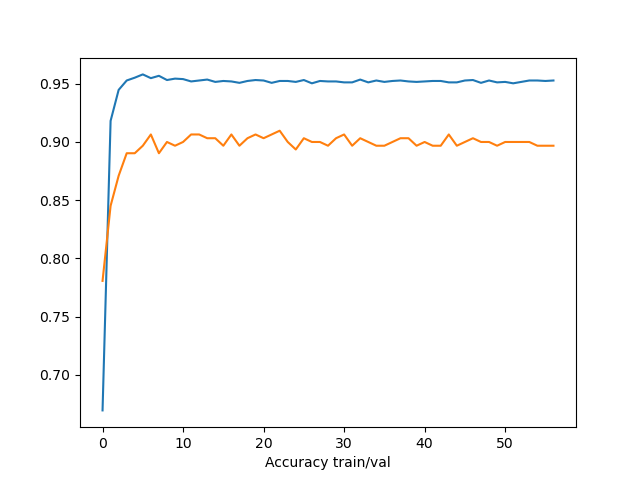

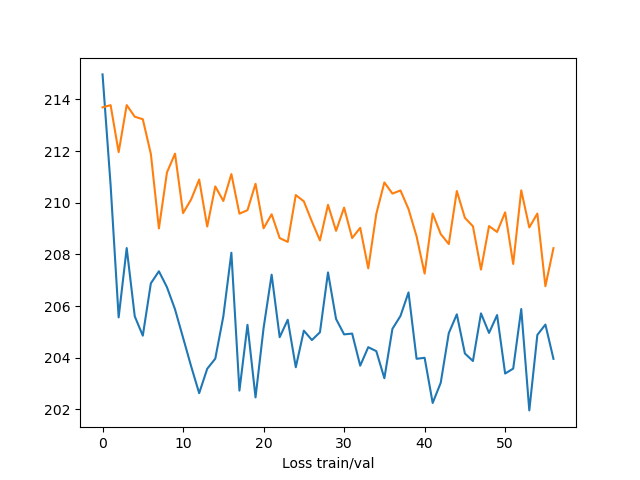

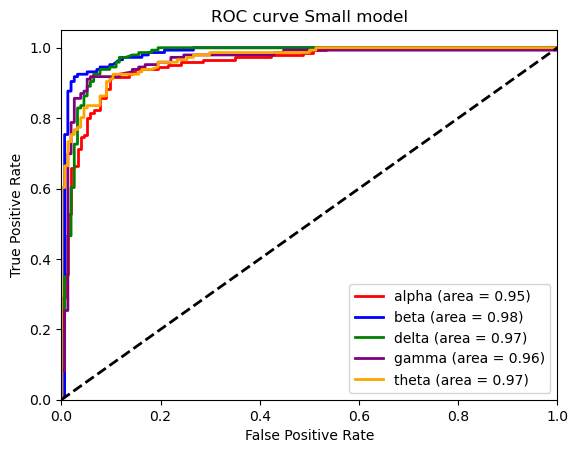

In [19]:
metrics = model.metrics_show()
# metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
best_mn = metrics[metrics['Dataset'] == 'Necker cube'].sort_values(by='Test Accuracy', ascending=False).iloc[0]
print('Best model')
print(best_mn, '\n')
dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{best_mn.iloc[2]}_{best_mn.iloc[3]}/"

print('Classification report')
classification_report_file = f'{dir}classification_report.pkl'
with open(classification_report_file, 'rb') as f:
    loaded_report = pickle.load(f)
report_df = pd.DataFrame(loaded_report).transpose()
print(report_df, '\n')

accuracy_file = f'{dir}accuracy.png'
display(IPImage(filename=accuracy_file))

loss_file = f'{dir}loss.png'
display(IPImage(filename=loss_file))



fpr = {}
tpr = {}
roc_auc = {}
i = 0

for rhythm in Config.RHYTHMS:
    
    dir = f"{LOG_DIR}{best_mn.iloc[0]}_{best_mn.iloc[1].replace(' ', '_')}_{rhythm}_{best_mn.iloc[3]}/"
    roc_auc_pred_file = f'{dir}roc_pred.pkl'
    roc_auc_true_file = f'{dir}roc_true_dump.pkl'
    with open(roc_auc_pred_file, 'rb') as f:
        roc_auc_pred = pickle.load(f)
    with open(roc_auc_true_file, 'rb') as f:
        roc_auc_true = pickle.load(f)    
    targets_pred = roc_auc_pred
    targets_true = roc_auc_true
    fpr[i], tpr[i], _ = roc_curve(targets_true, targets_pred)
    roc_auc[i] = roc_auc_score(targets_true, targets_pred)
    i = i+1


# Параметры для построения всех ROC-кривых на одном графике
plt.figure()
colors = ['red', 'blue', 'green', 'purple', 'orange']
for i, color in zip(range(len(roc_auc)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label='{0} (area = {1:0.2f})'
                   ''.format(Config.RHYTHMS[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC curve {best_mn.iloc[0]} model')
plt.legend(loc="lower right")
plt.show()

# Shap

In [20]:
best_mn.iloc[2]

'beta'

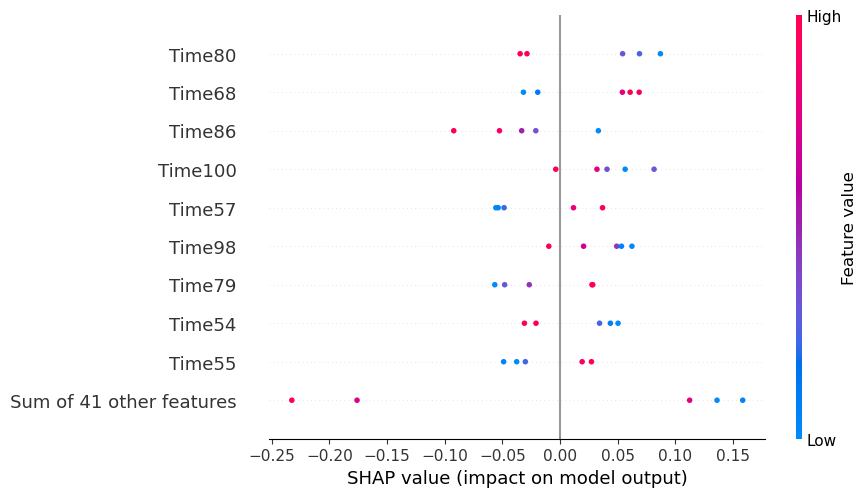

In [40]:
time_samples = 50
max_samples = 5

ds = CustomDataset('Mona Lisa', 'alpha', DATASET, True, max_samples)
# ds = CustomDataset(best_mn.iloc[1], best_mn.iloc[2], DATASET, True, 5)

class ShapModel(nn.Module):
    def __init__(self):
        super(ShapModel, self).__init__()
        self.linear_stack = nn.Sequential(
            nn.Linear(time_samples, 1000, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(1000),
            nn.Linear(1000, 10, bias=False),
            nn.ReLU(),
            nn.BatchNorm1d(10),
            nn.Linear(10, 1, bias=False),
            nn.Sigmoid(),
        )    
        
    def forward(self, x):

        x = torch.tensor(data=x.to_numpy(), dtype=torch.float).to(torch.device('cpu'))
        x = self.linear_stack(x)
        x = x.squeeze()
        return x

model = ShapModel()        


set_seed(Config.seed)

shap.initjs()
X = ds.dataframe
X = X.iloc[:,7:]
# X.drop('__index_level_0__', axis=1, inplace=True)

samples = X.iloc[np.random.choice(np.arange(len(X)), max_samples, replace=False)]

samples=samples.astype(float, errors="ignore")
background = samples.iloc[:, :time_samples]
values = samples.iloc[:, time_samples+1:2*time_samples+1]

#background=torch.tensor(background.values)

# self.__init__('Small', background.shape[1], background.shape[0])
# self.shap_mode = True
e = shap.Explainer(model, background, max_evals=samples.shape[1]*2+1)

#values=torch.tensor(values.values)

shap_values = e(values)
shap.plots.beeswarm(shap_values)

In [22]:
print(model)


ShapModel(
  (linear_stack): Sequential(
    (0): Linear(in_features=50, out_features=1000, bias=False)
    (1): ReLU()
    (2): BatchNorm1d(1000, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=1000, out_features=10, bias=False)
    (4): ReLU()
    (5): BatchNorm1d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): Linear(in_features=10, out_features=1, bias=False)
    (7): Sigmoid()
  )
)


In [24]:
samples

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time14991,Time14992,Time14993,Time14994,Time14995,Time14996,Time14997,Time14998,Time14999,Stratify
718,-17.222975533464833,-33.66995427040731,-48.46392085377934,-60.619527730238886,-69.29519940351098,-73.8566228745044,-73.91997076230646,-69.3775606080677,-60.41541770540657,-47.51060381777254,...,-5.143008057552931,-5.0759618997831515,-4.944167189445936,-4.716384424653434,-4.350633898272305,-3.8034746618978925,-3.0411773309216277,-2.0448142923816217,-0.81209793372896,C3-A1_0.4
2953,9.443968538068228,23.123364310009602,35.36794735918598,45.34304551312551,52.35976040404706,55.92580922789834,55.7884131534547,51.94792448855344,44.65440403618725,34.398325445041046,...,-18.439625227467882,-28.63468904842169,-37.09069311860916,-43.2258739586271,-46.613445827043925,-47.01113308885894,-44.37495182286844,-38.86684171427104,-30.84564871191182,Fp2-A2_0.6
1805,17.17628502874513,16.518185506228875,14.912404949916851,12.37460327189091,8.981762861140131,4.869882282633093,0.2266212280192333,-4.713140726480178,-9.676044512964756,-14.369415370100121,...,-5.427868548888862,-6.743268894239501,-6.993830002987616,-6.227786611217686,-4.5902145935299234,-2.304336581196149,0.34808255690718237,3.054103471321156,5.498485320534975,F3-A1_0.9
1612,-13.816004669662279,-15.490364878811302,-16.79421574670392,-17.57864309728519,-17.69105784262837,-16.989459317394893,-15.355470571766299,-12.711365838436128,-9.038136536785508,-4.388073054924914,...,37.508468231341254,50.01551758255706,59.17850811995146,64.45805588764738,65.58358646928144,62.56701956231737,55.696977441436786,45.51176136142588,32.75691105581529,O2-A2_0.3
1190,-5.097572003659807,-6.165009699782565,-7.38109113149865,-8.615614861914846,-9.698839049354698,-10.445140968459445,-10.674215845237804,-10.22256543448342,-8.96112821310287,-6.82149927033935,...,-25.172721780308766,-22.13340970113452,-17.555426671479395,-11.744959942738397,-5.100638176781301,1.921202349361737,8.841617047935825,15.184847670966699,20.513675372056067,T4-A2_0.9


In [25]:
background

,Time0,Time1,Time2,Time3,Time4,Time5,Time6,Time7,Time8,Time9,...,Time40,Time41,Time42,Time43,Time44,Time45,Time46,Time47,Time48,Time49
718,-17.222975533464833,-33.66995427040731,-48.46392085377934,-60.619527730238886,-69.29519940351098,-73.8566228745044,-73.91997076230646,-69.3775606080677,-60.41541770540657,-47.51060381777254,...,64.10935540758547,77.53038680731402,85.99985902444605,88.93312123051705,86.10053797257152,77.64570932400824,64.07866954146621,46.249324242536495,25.300873922842,2.5948164878154754
2953,9.443968538068228,23.123364310009602,35.36794735918598,45.34304551312551,52.35976040404706,55.92580922789834,55.7884131534547,51.94792448855344,44.65440403618725,34.398325445041046,...,-32.26326577919488,-36.77781438447757,-38.9470263521729,-38.77179166814214,-36.398743099919855,-32.108898419119576,-26.278274642237648,-19.337409892112404,-11.751237728461277,-3.98856216536639
1805,17.17628502874513,16.518185506228875,14.912404949916851,12.37460327189091,8.981762861140131,4.869882282633093,0.2266212280192333,-4.713140726480178,-9.676044512964756,-14.369415370100121,...,-30.279238124922806,-26.66338139361711,-21.392383691787504,-14.819805520187847,-7.388988000741949,0.40058638809517594,8.027696927046724,14.98387647747675,20.81029725405957,25.13282798032125
1612,-13.816004669662279,-15.490364878811302,-16.79421574670392,-17.57864309728519,-17.69105784262837,-16.989459317394893,-15.355470571766299,-12.711365838436128,-9.038136536785508,-4.388073054924914,...,52.66755841830107,64.94418596766955,73.72033286971688,78.33084835301578,78.35769988830349,73.66577300429634,64.41907384066037,51.07779463872656,34.37704107077163,15.281524020546662
1190,-5.097572003659807,-6.165009699782565,-7.38109113149865,-8.615614861914846,-9.698839049354698,-10.445140968459445,-10.674215845237804,-10.22256543448342,-8.96112821310287,-6.82149927033935,...,36.655123976064445,45.9354636023666,52.606151883456484,56.13372730844719,56.18174745094969,52.63967824456114,45.63027938805292,35.51157442985149,22.863672008252177,8.451231466167556


In [26]:
values

,Time51,Time52,Time53,Time54,Time55,Time56,Time57,Time58,Time59,Time60,...,Time91,Time92,Time93,Time94,Time95,Time96,Time97,Time98,Time99,Time100
718,-42.107059800350946,-61.12468496950857,-76.14448203464279,-86.1348599086047,-90.38769411848449,-88.56782523182474,-80.74868953700494,-67.41205653818683,-49.41225712543958,-27.926816944756336,...,107.19829335557004,103.02128338725649,91.61660426849926,73.70707134623376,50.482440057471415,23.51882152775075,-5.337000943175718,-34.09394660478036,-60.749133857140144,-83.43228403963069
2953,10.399636216416347,16.3392700989271,21.111840123888367,24.589307610038624,26.725576074797303,27.54127287386771,27.123946060581176,25.609729707755996,23.15249520859961,19.917572408548338,...,24.57843617843153,16.419401388817203,7.004071504648116,-3.1566820560687665,-13.481825069812524,-23.348514002459403,-32.137625433943896,-39.281735027696925,-44.297447104910795,-46.81773840492131
1805,28.337604499608663,27.07911534923332,24.04711117029665,19.50001693044245,13.797928569082549,7.37752347228308,0.7214861780910901,-5.680790002069134,-11.371140542776843,-15.954401157324758,...,13.844176131206538,17.567469169270872,20.045469530450738,21.02875599589167,20.38042014258563,18.08834056943906,14.273404693132678,9.180887498826255,3.159446625072836,-3.3619509599638002
1612,-25.45018499763038,-44.59012941160516,-61.29548481337617,-74.50806085728262,-83.37873314394248,-87.32668903826368,-86.07973807310897,-79.69302822598902,-68.54585837778684,-53.31917397819659,...,26.941335560921786,36.22511131050455,42.94000174407271,46.881272649635804,48.02598595054085,46.52316788206544,42.6672586343991,36.865772789419196,29.605800304335744,21.41674388985763
1190,-21.988046680796646,-36.03487635392794,-48.01792701814771,-57.10546292115817,-62.6404765835243,-64.19063310399372,-61.58326736682797,-54.92301868967133,-44.58968698462496,-31.217595740394614,...,69.0357632001493,70.78150555317717,67.47868540079328,59.30675374297529,46.792117335740386,30.777530285510185,12.366201651748256,-7.153717205968579,-26.39899103883673,-43.9897105863261


In [35]:
samples.dtypes

Time0        object
Time1        object
Time2        object
Time3        object
Time4        object
              ...  
Time14996    object
Time14997    object
Time14998    object
Time14999    object
Stratify     object
Length: 15001, dtype: object

In [39]:
help(samples.astype)

Help on method astype in module pandas.core.generic:

astype(dtype, copy: 'bool_t | None' = None, errors: 'IgnoreRaise' = 'raise') -> 'Self' method of pandas.core.frame.DataFrame instance
    Cast a pandas object to a specified dtype ``dtype``.
    
    Parameters
    ----------
    dtype : str, data type, Series or Mapping of column name -> data type
        Use a str, numpy.dtype, pandas.ExtensionDtype or Python type to
        cast entire pandas object to the same type. Alternatively, use a
        mapping, e.g. {col: dtype, ...}, where col is a column label and dtype is
        a numpy.dtype or Python type to cast one or more of the DataFrame's
        columns to column-specific types.
    copy : bool, default True
        Return a copy when ``copy=True`` (be very careful setting
        ``copy=False`` as changes to values then may propagate to other
        pandas objects).
    
        .. note::
            The `copy` keyword will change behavior in pandas 3.0.
            `Copy-

In [41]:
help(e)

Help on PermutationExplainer in module shap.explainers._permutation object:

class PermutationExplainer(PermutationExplainer)
 |  PermutationExplainer(model, masker, link=CPUDispatcher(<function identity at 0x7f0201684ae0>), feature_names=None, linearize_link=True, seed=None, **call_args)
 |  
 |  # this signature should match the __call__ signature of the class defined below
 |  
 |  Method resolution order:
 |      PermutationExplainer
 |      PermutationExplainer
 |      shap.explainers._explainer.Explainer
 |      shap._serializable.Serializable
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __call__(self, *args, max_evals=30003, main_effects=False, error_bounds=False, batch_size='auto', outputs=None, silent=False)
 |      Explain the output of the model on the given arguments.
 |  
 |  ----------------------------------------------------------------------
 |  Methods inherited from PermutationExplainer:
 |  
 |  __init__(self, model, masker, link=CPUDispatcher(<fu